In [ ]:
# Qubit Operator Algebra, Density Matrix, Bloch Sphere, Coherence, Entanglement Etc.

'''
This notebook demonstrates key concepts in quantum information:

1. Pauli Matrices
2. Qubit States
3. Density Matrices
4. Purity
5. Quantum Coherence
6. Entanglement
7. Bloch Sphere Representation

The goal is to provide an **interactive and visual understanding** of these concepts.

Mathematical tools used:
- NumPy (linear algebra)
- Matplotlib (visualization)
'''

'\nThis notebook demonstrates key concepts in quantum information:\n\n1. Pauli Matrices\n2. Qubit States\n3. Density Matrices\n4. Purity\n5. Quantum Coherence\n6. Entanglement\n7. Bloch Sphere Representation\n\nThe goal is to provide an **interactive and visual understanding** of these concepts.\n\nMathematical tools used:\n- NumPy (linear algebra)\n- Matplotlib (visualization)\n'

## Quantum Gates

Quantum gates are the basic building blocks of quantum circuits, analogous to classical logic gates. They are represented by unitary matrices that transform quantum states.

In [10]:
# Common Quantum Gates

# Pauli-X (NOT gate)
# Flips the qubit state: |0> <-> |1>
X = np.array([[0, 1],
              [1, 0]])

# Pauli-Y gate
# Rotates the qubit around the Y-axis by π radians
Y = np.array([[0, -1j],
              [1j, 0]])

# Pauli-Z gate
# Applies a phase of -1 to |1> state
Z = np.array([[1, 0],
              [0, -1]])

# Hadamard gate
# Creates superposition states: |0> -> (|0>+|1>)/sqrt(2), |1> -> (|0>-|1>)/sqrt(2)
H = 1/np.sqrt(2) * np.array([[1, 1],
                            [1, -1]])

# S gate (Phase gate)
S = np.array([[1, 0],
              [0, 1j]])

# T gate (π/8 gate)
T = np.array([[1, 0],
              [0, np.exp(1j*np.pi/4)]])

print("Pauli-X (NOT) gate:\n", X)
print("\nPauli-Y gate:\n", Y)
print("\nPauli-Z gate:\n", Z)
print("\nHadamard gate:\n", H)
print("\nS gate:\n", S)
print("\nT gate:\n", T)

Pauli-X (NOT) gate:
 [[0 1]
 [1 0]]

Pauli-Y gate:
 [[ 0.+0.j -0.-1.j]
 [ 0.+1.j  0.+0.j]]

Pauli-Z gate:
 [[ 1  0]
 [ 0 -1]]

Hadamard gate:
 [[ 0.70710678  0.70710678]
 [ 0.70710678 -0.70710678]]

S gate:
 [[1.+0.j 0.+0.j]
 [0.+0.j 0.+1.j]]

T gate:
 [[1.        +0.j         0.        +0.j        ]
 [0.        +0.j         0.70710678+0.70710678j]]


### Applying a Gate to a Qubit State

Hadamard gate transforms a |0> state into a superposition.

|0> state:
 [[1]
 [0]]

Hadamard applied to |0>:
 [[0.70710678]
 [0.70710678]]


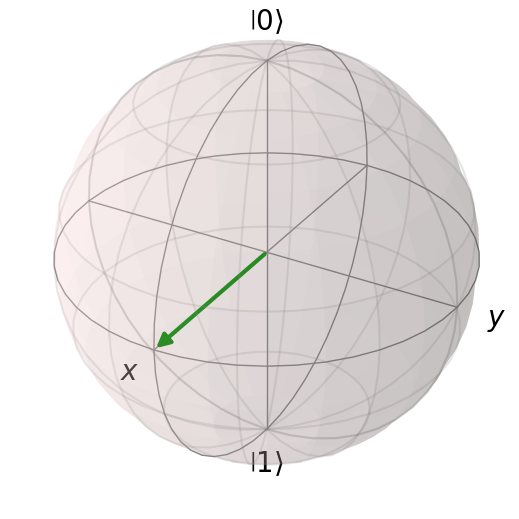


Pauli-X applied to |0>:
 [[0]
 [1]]


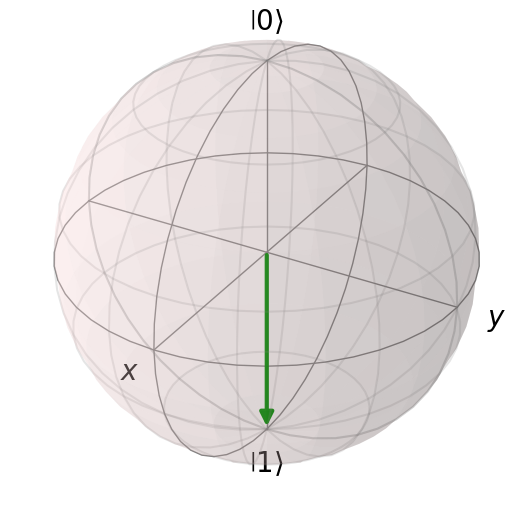

In [29]:
zero_state = np.array([[1],[0]])
one_state = np.array([[0],[1]])

# Apply Hadamard to |0>
superposition_state = H @ zero_state

print("|0> state:\n", zero_state)
print("\nHadamard applied to |0>:\n", superposition_state)

# Visualize on Bloch sphere
rho_superposition = density_matrix(superposition_state)
bl_vec_superposition = bloch_vector(rho_superposition)

b = Bloch()
b.add_vectors(bl_vec_superposition)
b.show()

# Apply Pauli-X to |0>
pauli_x_state = X @ zero_state
print("\nPauli-X applied to |0>:\n", pauli_x_state)

rho_pauli_x = density_matrix(pauli_x_state)
bl_vec_pauli_x = bloch_vector(rho_pauli_x)

b2 = Bloch()
b2.add_vectors(bl_vec_pauli_x)
b2.show()

# Qubit Operator Algebra, Density Matrix, Bloch Sphere, Coherence, Entanglement Etc.

'''
This notebook demonstrates key concepts in quantum information:

1. Pauli Matrices
2. Qubit States
3. Density Matrices
4. Purity
5. Quantum Coherence
6. Entanglement
7. Bloch Sphere Representation
8. Quantum Gates
9. Quantum Noise
10. Measurement Correlations

The goal is to provide an **interactive and visual understanding** of these concepts.

Mathematical tools used:
- NumPy (linear algebra)
- Matplotlib (visualization)
- QuTiP (Bloch Sphere visualization)
'''

In [41]:
# Install Libraries (QuTiP is useful for Bloch Sphere)
!pip install qutip --quiet
!pip install ipywidgets --quiet

import numpy as np
import matplotlib.pyplot as plt
from qutip import Bloch
from ipywidgets import interact, FloatSlider
from IPython.display import display, clear_output
import time

## Utility Functions for Bloch Sphere and Density Matrix Calculations


In [50]:
sigma_x = np.array([[0,1],[1,0]])
sigma_y = np.array([[0,-1j],[1j,0]])
sigma_z = np.array([[1,0],[0,-1]])
I = np.eye(2)

def state_from_angles(theta, phi):
    """
    Construct qubit state:

    |ψ> = cos(θ/2)|0> + e^{iφ} sin(θ/2)|1>
    """
    alpha = np.cos(theta/2)
    beta = np.exp(1j*phi)*np.sin(theta/2)

    psi = np.array([[alpha],[beta]])
    return psi

def density_matrix(psi):
    """
    Compute density matrix ρ = |ψ><ψ|
    """
    return psi @ psi.conj().T

def bloch_vector(rho):
    """
    Compute Bloch vector components

    r_i = Tr(ρ σ_i)
    """
    rx = np.trace(rho @ sigma_x).real
    ry = np.trace(rho @ sigma_y).real
    rz = np.trace(rho @ sigma_z).real

    return np.array([rx,ry,rz])

## 1. Pauli Matrices

Pauli matrices are fundamental in quantum mechanics, representing spin operators for a spin-1/2 particle. They form a basis for all 2x2 Hermitian matrices.

In [51]:
sigma_x_def = np.array([[0,1],[1,0]])
sigma_y_def = np.array([[0,-1j],[1j,0]])
sigma_z_def = np.array([[1,0],[0,-1]])

print("Sigma X\n",sigma_x_def)
print("\nSigma Y\n",sigma_y_def)
print("\nSigma Z\n",sigma_z_def)

Sigma X
 [[0 1]
 [1 0]]

Sigma Y
 [[ 0.+0.j -0.-1.j]
 [ 0.+1.j  0.+0.j]]

Sigma Z
 [[ 1  0]
 [ 0 -1]]


### Properties of Pauli Matrices

Important properties include their square being the identity matrix, anticommutation, and commutation relations.

In [52]:
print("σx^2 =\n", sigma_x_def @ sigma_x_def)
print("\nσy^2 =\n", sigma_y_def @ sigma_y_def)
print("\nσz^2 =\n", sigma_z_def @ sigma_z_def)

print("\nAnticommutator σxσy + σyσx =\n", sigma_x_def@sigma_y_def + sigma_y_def@sigma_x_def)

print("\nCommutator σxσy - σyσx =\n", sigma_x_def@sigma_y_def - sigma_y_def@sigma_x_def)

σx^2 =
 [[1 0]
 [0 1]]

σy^2 =
 [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

σz^2 =
 [[1 0]
 [0 1]]

Anticommutator σxσy + σyσx =
 [[0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]

Commutator σxσy - σyσx =
 [[0.+2.j 0.+0.j]
 [0.+0.j 0.-2.j]]


### Eigenvalues and Eigenvectors of Pauli Matrices

Pauli matrices have eigenvalues ±1, corresponding to measurements along their respective axes.

In [53]:
eigvals_y, eigvecs_y = np.linalg.eig(sigma_y_def)

print("Eigenvalues of σy:", eigvals_y)
print("\nEigenvectors:\n", eigvecs_y)

eigvals_z, eigvecs_z = np.linalg.eig(sigma_z_def)
print("\nEigenvalues of σz:", eigvals_z)

Eigenvalues of σy: [ 1.+0.j -1.+0.j]

Eigenvectors:
 [[-0.        -0.70710678j  0.70710678+0.j        ]
 [ 0.70710678+0.j          0.        -0.70710678j]]

Eigenvalues of σz: [ 1. -1.]


## 2. Qubit States

A general qubit state is a superposition of the basis states $|0\rangle$ and $|1\rangle$.

In [54]:
alpha = 1/np.sqrt(2)
beta = 1/np.sqrt(2)

psi = np.array([[alpha],[beta]])

print("Qubit state |ψ>:\n", psi)

Qubit state |ψ>:
 [[0.70710678]
 [0.70710678]]


## 3. Density Matrices

Density matrices provide a more general description of quantum states, including mixed states (probabilistic mixtures of pure states).

In [55]:
# Density Matrix of the Pure State
rho = psi @ psi.conj().T

print("Density matrix for |ψ> = (|0> + |1>)/√2 :\n", rho)

Density matrix for |ψ> = (|0> + |1>)/√2 :
 [[0.5 0.5]
 [0.5 0.5]]


### Properties of Density Matrices

Density matrices are Hermitian, have a trace of 1, and are positive semi-definite.

In [56]:
print("Trace:", np.trace(rho))
print("Hermitian check:", np.allclose(rho, rho.conj().T))

eigvals_rho = np.linalg.eigvals(rho)
print("Eigenvalues:", eigvals_rho)

Trace: 0.9999999999999998
Hermitian check: True
Eigenvalues: [1. 0.]


### Mixed State Example

A mixed state is a classical probability distribution over pure states.

In [57]:
p = 0.6 # Probability of being in |0>

rho_mixed = np.array([
    [p,0],
    [0,1-p]
])

print("Mixed state density matrix (p=0.6 for |0> and 0.4 for |1>):\n", rho_mixed)

Mixed state density matrix (p=0.6 for |0> and 0.4 for |1>):
 [[0.6 0. ]
 [0.  0.4]]


## 4. Purity

In [58]:
purity_pure = np.trace(rho @ rho)
print("Purity of the pure state |ψ>:\n", purity_pure)

purity_mixed = np.trace(rho_mixed @ rho_mixed)
print("\nPurity of the mixed state:\n", purity_mixed)

Purity of the pure state |ψ>:
 0.9999999999999996

Purity of the mixed state:
 0.52


## 5. Quantum Coherence

Coherence refers to the superposition principle in quantum mechanics, reflected in the off-diagonal elements of the density matrix. Its magnitude indicates the degree of superposition.

In [59]:
coherence = 2 * abs(rho[0,1]) # For a single qubit, |ρ01| = |ρ10|

print("Coherence magnitude for |ψ> = (|0> + |1>)/√2 :", coherence)

Coherence magnitude for |ψ> = (|0> + |1>)/√2 : 0.9999999999999998


### Example of Phase Damping (Loss of Coherence)

Noise channels can cause quantum systems to lose coherence, a process known as decoherence. Phase damping selectively reduces the off-diagonal elements.

In [60]:
gamma = 0.2 # Decoherence factor (0 for no decoherence, 1 for full decoherence)

rho_damped = np.array([
    [rho[0,0], gamma*rho[0,1]],
    [gamma*rho[1,0], rho[1,1]]
])

print("Density matrix after phase damping (gamma=0.2):\n", rho_damped)

coherence_damped = 2 * abs(rho_damped[0,1])
print("\nCoherence magnitude after damping:", coherence_damped)

Density matrix after phase damping (gamma=0.2):
 [[0.5 0.1]
 [0.1 0.5]]

Coherence magnitude after damping: 0.19999999999999996


## 6. Quantum Gates

Quantum gates are unitary operations that transform quantum states. They are the building blocks of quantum circuits.

In [61]:
# Common Quantum Gates

# Pauli-X (NOT gate)
# Flips the qubit state: |0> <-> |1>
X = np.array([[0, 1],
              [1, 0]])

# Pauli-Y gate
# Rotates the qubit around the Y-axis by π radians
Y = np.array([[0, -1j],
              [1j, 0]])

# Pauli-Z gate
# Applies a phase of -1 to |1> state
Z = np.array([[1, 0],
              [0, -1]])

# Hadamard gate
# Creates superposition states: |0> -> (|0>+|1>)/sqrt(2), |1> -> (|0>-|1>)/sqrt(2)
H = 1/np.sqrt(2) * np.array([[1, 1],
                            [1, -1]])

# S gate (Phase gate)
S = np.array([[1, 0],
              [0, 1j]])

# T gate (π/8 gate)
T = np.array([[1, 0],
              [0, np.exp(1j*np.pi/4)]])

print("Pauli-X (NOT) gate:\n", X)
print("\nPauli-Y gate:\n", Y)
print("\nPauli-Z gate:\n", Z)
print("\nHadamard gate:\n", H)
print("\nS gate:\n", S)
print("\nT gate:\n", T)

Pauli-X (NOT) gate:
 [[0 1]
 [1 0]]

Pauli-Y gate:
 [[ 0.+0.j -0.-1.j]
 [ 0.+1.j  0.+0.j]]

Pauli-Z gate:
 [[ 1  0]
 [ 0 -1]]

Hadamard gate:
 [[ 0.70710678  0.70710678]
 [ 0.70710678 -0.70710678]]

S gate:
 [[1.+0.j 0.+0.j]
 [0.+0.j 0.+1.j]]

T gate:
 [[1.        +0.j         0.        +0.j        ]
 [0.        +0.j         0.70710678+0.70710678j]]


### Applying a Gate to a Qubit State

Applying some gates to basis states and visualize the result on the Bloch sphere.

|0> state:
 [[1]
 [0]]

Hadamard applied to |0>:
 [[0.70710678]
 [0.70710678]]


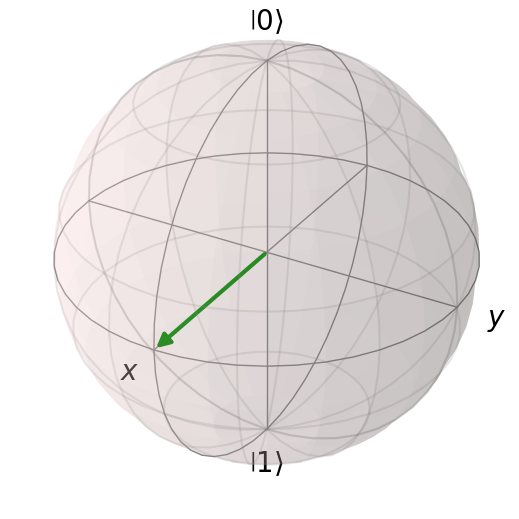


Pauli-X applied to |0>:
 [[0]
 [1]]


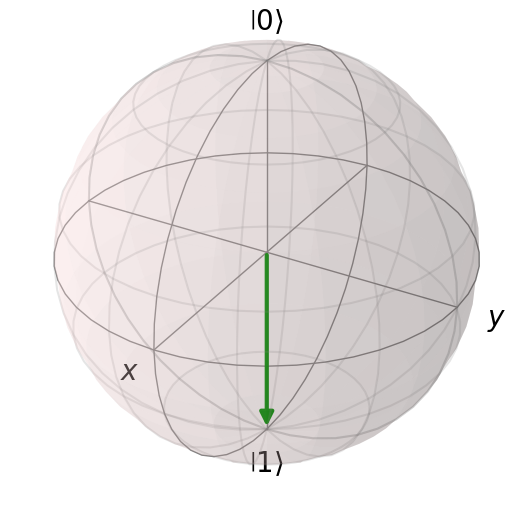

In [62]:
zero_state = np.array([[1],[0]])
one_state = np.array([[0],[1]])

# Apply Hadamard to |0>
superposition_state = H @ zero_state

print("|0> state:\n", zero_state)
print("\nHadamard applied to |0>:\n", superposition_state)

# Visualize on Bloch sphere
rho_superposition = density_matrix(superposition_state)
bl_vec_superposition = bloch_vector(rho_superposition)

b_h = Bloch()
b_h.add_vectors(bl_vec_superposition)
b_h.show()

# Apply Pauli-X to |0>
pauli_x_state = X @ zero_state
print("\nPauli-X applied to |0>:\n", pauli_x_state)

rho_pauli_x = density_matrix(pauli_x_state)
bl_vec_pauli_x = bloch_vector(rho_pauli_x)

b_x = Bloch()
b_x.add_vectors(bl_vec_pauli_x)
b_x.show()

## 7. Bloch Sphere Representation

The Bloch sphere is a geometrical representation of the state space of a single qubit. Any pure state can be mapped to a point on its surface.

In [24]:
# Bloch Vector from Density Matrix

rx_pure = np.trace(rho @ sigma_x).real
ry_pure = np.trace(rho @ sigma_y).real
rz_pure = np.trace(rho @ sigma_z).real

bloch_vector_pure = np.array([rx_pure,ry_pure,rz_pure])

print("Bloch vector for |ψ> = (|0> + |1>)/√2 :", bloch_vector_pure)
print("Length:", np.linalg.norm(bloch_vector_pure))

Bloch vector for |ψ> = (|0> + |1>)/√2 : [1. 0. 0.]
Length: 0.9999999999999998


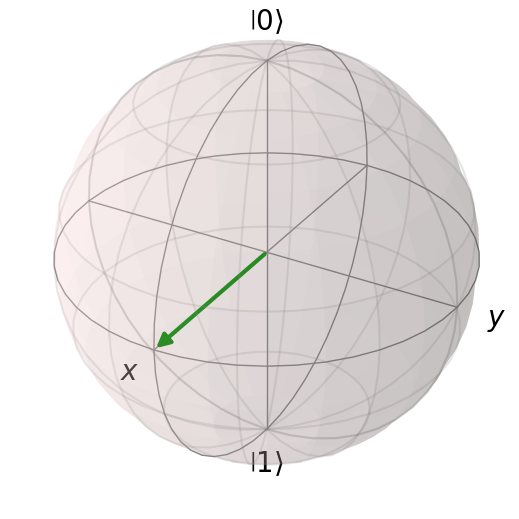

In [63]:
# Bloch Sphere Visualization (Pure State)

b_pure = Bloch()
b_pure.add_vectors(bloch_vector_pure)
b_pure.show()

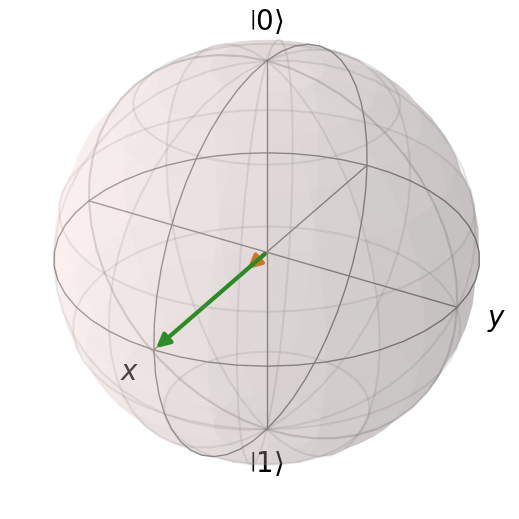

In [67]:
# Bloch vector after Decoherence

rx_damped = np.trace(rho_damped @ sigma_x).real
ry_damped = np.trace(rho_damped @ sigma_y).real
rz_damped = np.trace(rho_damped @ sigma_z).real

bloch_vector_damped = [rx_damped,ry_damped,rz_damped]

b_damped = Bloch()
# Add both vectors to the Bloch sphere. QuTiP's add_vectors expects a list of vectors.
# Labels are typically added via a legend function or by plotting vectors individually.
# Removing the problematic string labels 'Pure State' and 'Damped State'.
b_damped.add_vectors([bloch_vector_pure, bloch_vector_damped])
b_damped.show()

### Interactive Bloch Sphere with Theta and Phi

Explore how changing the angles $\theta$ and $\phi$ affects the qubit's position on the Bloch sphere.

In [27]:
def interactive_bloch(theta, phi):

    psi_int = state_from_angles(theta, phi)
    rho_int = density_matrix(psi_int)

    r_int = bloch_vector(rho_int)

    b_int = Bloch()
    b_int.add_vectors(r_int)

    b_int.show()


print("Interactive Bloch Sphere: Adjust theta (polar angle) and phi (azimuthal angle).")
print("Changing θ --> Moves state north–south")
print("Changing φ --> Rotates state around z-axis")

interact(
    interactive_bloch,
    theta=FloatSlider(min=0,max=np.pi,step=0.05,value=np.pi/2),
    phi=FloatSlider(min=0,max=2*np.pi,step=0.05,value=0)
);

Interactive Bloch Sphere: Adjust theta (polar angle) and phi (azimuthal angle).
Changing θ --> Moves state north–south
Changing φ --> Rotates state around z-axis


interactive(children=(FloatSlider(value=1.5707963267948966, description='theta', max=3.141592653589793, step=0…

### Animated Rotations

Visualizing rotations around different axes on the Bloch sphere.

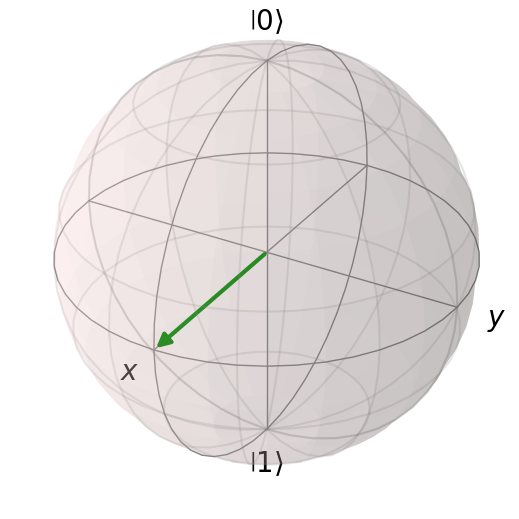

In [28]:
# Rotations around Z-Axis
# This simulates a unitary evolution: U=e−iθσz​/2

def animate_rotation_z():

    theta_init = np.pi/2 # Start with a state in the equatorial plane
    psi_rot_z = state_from_angles(theta_init,0)

    for phi_val in np.linspace(0,2*np.pi,30):

        psi_current = state_from_angles(theta_init,phi_val)
        rho_current = density_matrix(psi_current)
        r_current = bloch_vector(rho_current)

        clear_output(wait=True)

        b_anim_z = Bloch()
        b_anim_z.add_vectors(r_current)
        b_anim_z.show()

        time.sleep(0.1)

print("Animating rotation around the Z-axis...")
animate_rotation_z()

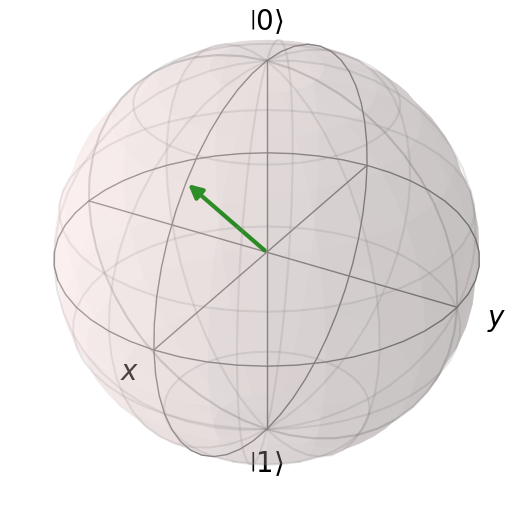

In [30]:
# Animated Rotations around X-axis
# This simulates: U=e−iθσx​/2

def rotation_x(theta_angle):

    return np.cos(theta_angle/2)*I - 1j*np.sin(theta_angle/2)*sigma_x

def animate_rotation_x():

    psi_rot_x = state_from_angles(np.pi/4,0) # Start with an arbitrary state

    for t_val in np.linspace(0,2*np.pi,30):

        U_x = rotation_x(t_val)

        psi_t = U_x @ psi_rot_x
        rho_t = density_matrix(psi_t)

        r_t = bloch_vector(rho_t)

        clear_output(wait=True)

        b_anim_x = Bloch()
        b_anim_x.add_vectors(r_t)
        b_anim_x.show()

        time.sleep(0.1)

print("Animating rotation around the X-axis...")
animate_rotation_x()

### Visualizing Bloch Sphere Coordinates

This demonstrates the mapping from spherical coordinates $(\theta, \phi)$ to Cartesian coordinates $(x,y,z)$ on the Bloch sphere, where $x=\sin\theta\cos\phi$, $y=\sin\theta\sin\phi$, and $z=\cos\theta$.

In [32]:
def bloch_coordinates(theta,phi):

    x = np.sin(theta)*np.cos(phi)
    y = np.sin(theta)*np.sin(phi)
    z = np.cos(theta)

    print("Bloch vector:")
    print("x =",x)
    print("y =",y)
    print("z =",z)


interact(
    bloch_coordinates,
    theta=FloatSlider(min=0,max=np.pi,step=0.05,value=np.pi/2),
    phi=FloatSlider(min=0,max=2*np.pi,step=0.05,value=0)
);

interactive(children=(FloatSlider(value=1.5707963267948966, description='theta', max=3.141592653589793, step=0…

## 8. Entanglement

Entanglement is a unique quantum phenomenon where two or more particles become linked, such that the state of one instantly influences the state of the others, regardless of distance.

In [33]:
# Two Qubit System Basis

zero_q = np.array([[1],[0]])
one_q = np.array([[0],[1]])

basis00 = np.kron(zero_q,zero_q) # |0> ⊗ |0>
basis01 = np.kron(zero_q,one_q)  # |0> ⊗ |1>
basis10 = np.kron(one_q,zero_q)  # |1> ⊗ |0>
basis11 = np.kron(one_q,one_q)  # |1> ⊗ |1>

print("|00> basis state:\n", basis00)

|00> basis state:
 [[1]
 [0]
 [0]
 [0]]


### Bell State (Maximally Entangled State)

The Bell states are a set of four maximally entangled two-qubit states.

In [34]:
# Bell State |Φ+> = (|00> + |11>) / √2

bell_phi_plus = (basis00 + basis11)/np.sqrt(2)

rho_bell = bell_phi_plus @ bell_phi_plus.conj().T

print("Bell state |Φ+> density matrix:\n", rho_bell)

Bell state |Φ+> density matrix:
 [[0.5 0.  0.  0.5]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.5 0.  0.  0.5]]


### Reduced Density Matrix of an Entangled State

For an entangled state, the individual subsystems are in a mixed state, even if the global state is pure. This is demonstrated by tracing out one of the qubits.

In [35]:
# Trace out the second qubit from rho_bell
# This results in a 2x2 matrix for the first qubit.

rho_A_bell = np.zeros((2,2), dtype=complex)
rho_A_bell[0,0] = rho_bell[0,0] + rho_bell[1,1] # Sum of diagonal elements where second qubit is |0>
rho_A_bell[1,1] = rho_bell[2,2] + rho_bell[3,3] # Sum of diagonal elements where second qubit is |1>

# Or, more generally, using partial trace (from QuTiP or manual calculation for 2 qubits)
# For a 2-qubit state ρ_AB, ρ_A = Tr_B(ρ_AB)
# rho_bell is already 4x4. To trace out the second qubit:
# rho_A = [[rho_bell[0,0] + rho_bell[1,1], rho_bell[0,2] + rho_bell[1,3]],
#          [rho_bell[2,0] + rho_bell[3,1], rho_bell[2,2] + rho_bell[3,3]]]

# For Bell state, the off-diagonal terms are zero after tracing out.
rho_A_bell_correct = np.array([
    [rho_bell[0,0] + rho_bell[2,2], rho_bell[0,1] + rho_bell[2,3]],
    [rho_bell[1,0] + rho_bell[3,2], rho_bell[1,1] + rho_bell[3,3]]
])
# Simplified for Bell state |Φ+>, it's just the identity matrix / 2
rho_A_bell_simplified = np.array([
    [0.5,0],
    [0,0.5]
])

print("Reduced density matrix of subsystem A (from Bell state):\n", rho_A_bell_simplified)

Reduced density matrix of subsystem A (from Bell state):
 [[0.5 0. ]
 [0.  0.5]]


In [36]:
# Purity of the reduced subsystem

purity_subsystem = np.trace(rho_A_bell_simplified @ rho_A_bell_simplified)

print("Purity of subsystem A from Bell state:", purity_subsystem)
print("Purity = 0.5, indicating maximal mixedness due to entanglement.")

Purity of subsystem A from Bell state: 0.5
Purity = 0.5, indicating maximal mixedness due to entanglement.


## 9. Quantum Noise Modeling (Purity and Coherence vs. Noise)

Quantum noise (decoherence) degrades quantum states. We will model a simple depolarizing channel, which randomly applies X, Y, or Z gates with a certain probability, effectively mixing the state.

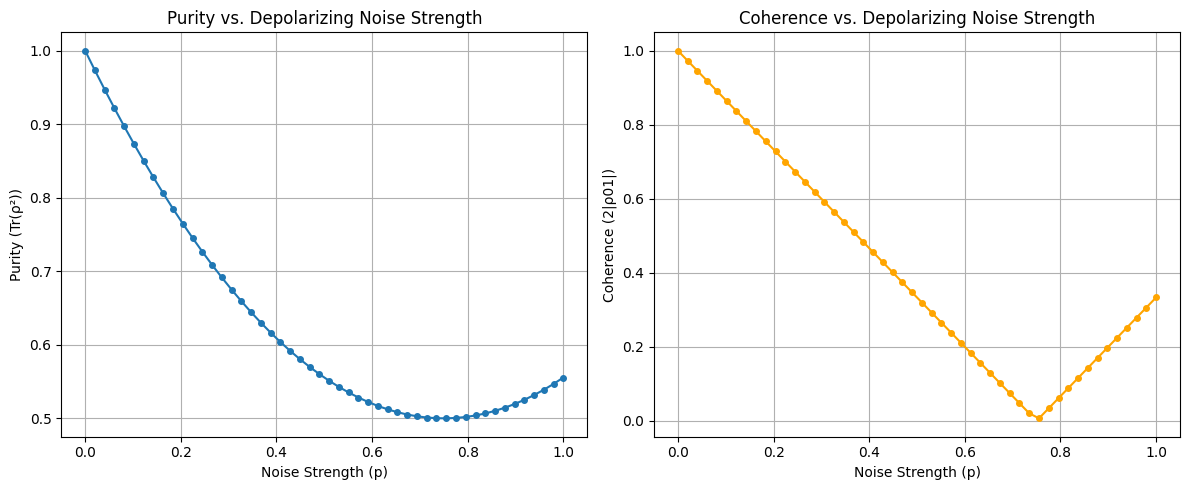

In [37]:
def depolarizing_channel(rho_in, p_noise):
    """
    Applies a depolarizing channel to a single qubit density matrix.
    rho_out = (1 - p_noise) * rho_in + (p_noise / 3) * (X @ rho_in @ X + Y @ rho_in @ Y + Z @ rho_in @ Z)
    """
    if not (0 <= p_noise <= 1):
        raise ValueError("Noise probability p_noise must be between 0 and 1.")

    # The identity operation is implicitly part of the (1-p_noise) term
    rho_out = (1 - p_noise) * rho_in + (p_noise / 3) * (sigma_x @ rho_in @ sigma_x + sigma_y @ rho_in @ sigma_y + sigma_z @ rho_in @ sigma_z)
    return rho_out


# Initial pure state (e.g., |+> state)
psi_plus = (zero_q + one_q) / np.sqrt(2)
rho_initial = density_matrix(psi_plus)

noise_strengths = np.linspace(0, 1, 50) # Probability of depolarizing error
purities = []
coherences = []

for p in noise_strengths:
    rho_noisy = depolarizing_channel(rho_initial, p)
    purities.append(np.trace(rho_noisy @ rho_noisy).real)
    coherences.append(2 * abs(rho_noisy[0,1]).real)


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(noise_strengths, purities, marker='o', markersize=4)
plt.title('Purity vs. Depolarizing Noise Strength')
plt.xlabel('Noise Strength (p)')
plt.ylabel('Purity (Tr(ρ²))')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(noise_strengths, coherences, marker='o', markersize=4, color='orange')
plt.title('Coherence vs. Depolarizing Noise Strength')
plt.xlabel('Noise Strength (p)')
plt.ylabel('Coherence (2|ρ01|)')
plt.grid(True)

plt.tight_layout()
plt.show()

## 10. Measurement Correlations

Measurement is a fundamental operation in quantum mechanics. For entangled states, measurements on one qubit instantaneously affect the state of the other, leading to correlations.

In [38]:
def measure_qubit(state_vector, num_shots=1000):
    """
    Simulates measurement of a single qubit in the computational basis.
    Returns counts for |0> and |1>.
    """
    prob_0 = abs(state_vector[0,0])**2
    prob_1 = abs(state_vector[1,0])**2

    outcomes = np.random.choice([0, 1], size=num_shots, p=[prob_0, prob_1])
    counts = {0: np.sum(outcomes == 0), 1: np.sum(outcomes == 1)}
    return counts

# Example: Measure the |+> state
psi_plus = (zero_q + one_q) / np.sqrt(2)
counts_plus = measure_qubit(psi_plus)
print(f"Measurement counts for |+> state over 1000 shots: {counts_plus}")

# Example: Measure the |0> state
counts_zero = measure_qubit(zero_q)
print(f"Measurement counts for |0> state over 1000 shots: {counts_zero}")

Measurement counts for |+> state over 1000 shots: {0: np.int64(488), 1: np.int64(512)}
Measurement counts for |0> state over 1000 shots: {0: np.int64(1000), 1: np.int64(0)}


### Measurement Correlations for Bell State

If we measure one qubit of a Bell state, say $|\Phi^+\rangle = (|00\rangle + |11\rangle) / \sqrt{2}$, in the Z-basis, and find it to be $|0\rangle$, the other qubit will also instantaneously be $|0\rangle$. This perfect correlation is a hallmark of entanglement.

Joint measurement counts for 5000 shots (Bell |Φ+>): {'00': 2508, '01': 0, '10': 0, '11': 2492}

When Qubit 1 is measured as 0, Qubit 2 was 0: 2508 times
When Qubit 1 is measured as 0, Qubit 2 was 1: 0 times
When Qubit 1 is measured as 1, Qubit 2 was 0: 0 times
When Qubit 1 is measured as 1, Qubit 2 was 1: 2492 times

--- Visualizing with a correlation plot ---


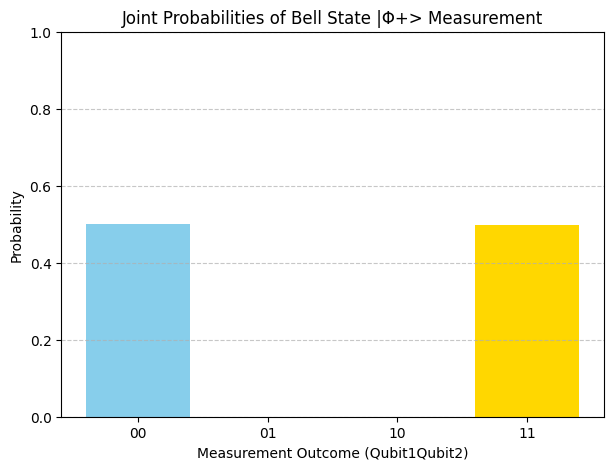

In [66]:
def simulate_bell_measurements(bell_state, num_shots=1000):
    """
    Simulates measurements on both qubits of a two-qubit Bell state.
    Assumes measurement in the computational (Z) basis.
    """
    # Probabilities for |00>, |01>, |10>, |11>
    probs = np.array([abs(bell_state[i,0])**2 for i in range(4)])
    probs /= np.sum(probs) # Ensure probabilities sum to 1

    # Generate outcomes for each shot
    outcomes_idx = np.random.choice(range(4), size=num_shots, p=probs)

    # Map indices back to |00>, |01>, |10>, |11>
    # 0 -> '00', 1 -> '01', 2 -> '10', 3 -> '11'
    str_outcomes = [format(i, '02b') for i in outcomes_idx]

    q1_results = [int(s[0]) for s in str_outcomes]
    q2_results = [int(s[1]) for s in str_outcomes]

    # Calculate joint and conditional probabilities/counts
    joint_counts = {'00':0, '01':0, '10':0, '11':0}
    for outcome_str in str_outcomes:
        joint_counts[outcome_str] += 1

    print(f"Joint measurement counts for {num_shots} shots (Bell |Φ+>): {joint_counts}")

    # Verify correlations: if Q1 is 0, Q2 must be 0; if Q1 is 1, Q2 must be 1
    q1_0_q2_0 = joint_counts['00']
    q1_0_q2_1 = joint_counts['01']
    q1_1_q2_0 = joint_counts['10']
    q1_1_q2_1 = joint_counts['11']

    print(f"\nWhen Qubit 1 is measured as 0, Qubit 2 was 0: {q1_0_q2_0} times")
    print(f"When Qubit 1 is measured as 0, Qubit 2 was 1: {q1_0_q2_1} times")
    print(f"When Qubit 1 is measured as 1, Qubit 2 was 0: {q1_1_q2_0} times")
    print(f"When Qubit 1 is measured as 1, Qubit 2 was 1: {q1_1_q2_1} times")

    # This should ideally show q1_0_q2_1 and q1_1_q2_0 are close to 0 for |Φ+>
    return joint_counts

# Create a Bell state |Φ+>
bell_phi_plus_state = (basis00 + basis11) / np.sqrt(2)
joint_counts_result = simulate_bell_measurements(bell_phi_plus_state, num_shots=5000)

print("\n--- Visualizing with a correlation plot ---")
# For visualization, let's just plot the joint probabilities
states = ['00', '01', '10', '11']
counts = np.array([joint_counts_result[s] for s in states])
probabilities = counts / np.sum(counts)

plt.figure(figsize=(7, 5))
plt.bar(states, probabilities, color=['skyblue', 'salmon', 'lightgreen', 'gold'])
plt.title('Joint Probabilities of Bell State |Φ+> Measurement')
plt.xlabel('Measurement Outcome (Qubit1Qubit2)')
plt.ylabel('Probability')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Summary

'''
Key Takeaways
State: ∣ψ⟩=cos(θ/2)∣0⟩+eiϕsin(θ/2)∣1⟩
Bloch Vector: r=(sinθcosϕ,sinθsinϕ,cosθ)

Pauli matrices: Form basis for qubit operators

Density matrices: Describe both pure and mixed states

Purity: Measures classical uncertainty

Coherence: Comes from off-diagonal terms

Bloch sphere: Visual representation of qubit states

Entanglement: Subsystems appear mixed even if the global state is pure

Quantum Gates: Unitary operations that transform qubit states

Quantum Noise: Channels that cause decoherence, reducing purity and coherence

Measurement Correlations: Demonstrates non-local correlations in entangled states
'''

In [ ]:
# Install Libraries (QuTiP is useful for Bloch Sphere)
!pip install qutip --quiet

import numpy as np
import matplotlib.pyplot as plt
from qutip import Bloch

!pip install qutip ipywidgets --quiet
from ipywidgets import interact, FloatSlider
from IPython.display import display

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.1/33.1 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 32.4 MB/s eta 0:00:00


In [ ]:
# Pauli Matrices
"""
Pauli matrices (along with Identity) form a basis for all 2×2 Hermitian operators.

σx = [[0,1],
      [1,0]]

σy = [[0,-i],
      [i,0]]

σz = [[1,0],
      [0,-1]]
"""

sigma_x = np.array([[0,1],[1,0]])
sigma_y = np.array([[0,-1j],[1j,0]])
sigma_z = np.array([[1,0],[0,-1]])

I = np.eye(2)

print("Sigma X\n",sigma_x)
print("\nSigma Y\n",sigma_y)
print("\nSigma Z\n",sigma_z)

Sigma X
 [[0 1]
 [1 0]]

Sigma Y
 [[ 0.+0.j -0.-1.j]
 [ 0.+1.j  0.+0.j]]

Sigma Z
 [[ 1  0]
 [ 0 -1]]


In [ ]:
# Properties of Pauli Matrices

"""
Important properties:

1. σ_i^2 = I
2. {σ_i, σ_j} = 2δ_ij I (anticommutation)
3. [σ_i, σ_j] = 2i ε_ijk σ_k (commutation)
"""

print("σx^2 =\n", sigma_x @ sigma_x)
print("\nσy^2 =\n", sigma_y @ sigma_y)
print("\nσz^2 =\n", sigma_z @ sigma_z)

print("\nAnticommutator σxσy + σyσx =\n", sigma_x@sigma_y + sigma_y@sigma_x)

print("\nCommutator σxσy - σyσx =\n", sigma_x@sigma_y - sigma_y@sigma_x)

σx^2 =
 [[1 0]
 [0 1]]

σy^2 =
 [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

σz^2 =
 [[1 0]
 [0 1]]

Anticommutator σxσy + σyσx =
 [[0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]

Commutator σxσy - σyσx =
 [[0.+2.j 0.+0.j]
 [0.+0.j 0.-2.j]]


In [ ]:
# Eigenvectors and Eigenvalues of the Pauli Matrices

"""
Pauli matrices have eigenvalues ±1.

They represent measurements along x, y, z directions.
"""

eigvals, eigvecs = np.linalg.eig(sigma_y)

print("Eigenvalues of σy:", eigvals)
print("\nEigenvectors:\n", eigvecs)

Eigenvalues of σy: [ 1.+0.j -1.+0.j]

Eigenvectors:
 [[-0.        -0.70710678j  0.70710678+0.j        ]
 [ 0.70710678+0.j          0.        -0.70710678j]]


In [ ]:
# Define Qubit State

"""
A general qubit:

|ψ> = α|0> + β|1>

with normalization:

|α|² + |β|² = 1
"""

alpha = 1/np.sqrt(2)
beta = 1/np.sqrt(2)

psi = np.array([[alpha],[beta]])

print("Qubit state |ψ>:\n", psi)

Qubit state |ψ>:
 [[0.70710678]
 [0.70710678]]


In [ ]:
# Density Matrix of the Pure State

"""
Density matrix definition:

ρ = |ψ><ψ|
"""

rho = psi @ psi.conj().T

print("Density matrix:\n", rho)

Density matrix:
 [[0.5 0.5]
 [0.5 0.5]]


In [ ]:
# Properties of the Density Matrices

"""
Density matrix properties:

1. Hermitian
2. Trace = 1
3. Positive semi-definite
"""

print("Trace:", np.trace(rho))
print("Trace of square:", np.trace(rho @ rho))
print("Hermitian check:", np.allclose(rho, rho.conj().T))

eigvals = np.linalg.eigvals(rho)
print("Eigenvalues:", eigvals)

Trace: 0.9999999999999998
Trace of square: 0.9999999999999996
Hermitian check: True
Eigenvalues: [1. 0.]


In [ ]:
# Purity of Quantum State

"""
Purity measure:

Purity = Tr(ρ²)

Pure state → Purity = 1
Mixed state → Purity < 1
"""

purity = np.trace(rho @ rho)

print("Purity =", purity)

Purity = 0.9999999999999996


In [ ]:
# Mixed State Example

"""
Mixed state:
ρ = p |0><0| + (1-p)|1><1|
"""

p = 0.6

rho_mixed = np.array([
    [p,0],
    [0,1-p]
])

print("Mixed state density matrix:\n", rho_mixed)

purity = np.trace(rho_mixed @ rho_mixed)
print("\nPurity:", purity)

Mixed state density matrix:
 [[0.6 0. ]
 [0.  0.4]]

Purity: 0.52


In [ ]:
# Quantum Coherence

"""
Coherence corresponds to the OFF-DIAGONAL terms of the density matrix.

ρ = [[ρ00 , ρ01],
     [ρ10 , ρ11]]

ρ01 and ρ10 represent coherence.
"""

coherence = 2*abs(rho[0,1])

print("Coherence magnitude:", coherence)

Coherence magnitude: 0.9999999999999998


In [ ]:
# Example of Phase Damping (Loss of Coherence)
"""
Phase damping removes coherence.

ρ' = [[ρ00 , γρ01],
      [γρ10 , ρ11]]
"""

gamma = 0.2

rho_damped = np.array([
    [rho[0,0], gamma*rho[0,1]],
    [gamma*rho[1,0], rho[1,1]]
])

print("Density matrix after decoherence:\n", rho_damped)

Density matrix after decoherence:
 [[0.5 0.1]
 [0.1 0.5]]


In [ ]:
# Two Qubit System

"""
Now we explore entanglement.

Basis:

|00>, |01>, |10>, |11>
"""

zero = np.array([[1],[0]])
one = np.array([[0],[1]])

basis00 = np.kron(zero,zero)
basis11 = np.kron(one,one)

In [ ]:
# Bell State

"""
Bell state:

|Φ+> = (|00> + |11>) / √2
"""

bell = (basis00 + basis11)/np.sqrt(2)

rho_bell = bell @ bell.conj().T

print("Bell state density matrix:\n", rho_bell)

Bell state density matrix:
 [[0.5 0.  0.  0.5]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.5 0.  0.  0.5]]


In [ ]:
# Reduced Density Matrix of the Bell State

"""
Trace out second qubit.

Entanglement test:
Each qubit individually appears maximally mixed.
"""

rho_A = np.array([
    [0.5,0],
    [0,0.5]
])

print("Reduced density matrix:\n", rho_A)

Reduced density matrix:
 [[0.5 0. ]
 [0.  0.5]]


In [ ]:
# Purity of the reduced states

purity = np.trace(rho_A @ rho_A)

print("Purity of subsystem:", purity)

# Purity = 0.5, indicating maximal mixedness due to entanglement.

Purity of subsystem: 0.5


In [ ]:
# Bloch Vector from Density Matrix

"""
Any qubit density matrix can be written as:

ρ = (1/2)(I + r·σ)

where r = Bloch vector
"""

rx = np.trace(rho @ sigma_x).real
ry = np.trace(rho @ sigma_y).real
rz = np.trace(rho @ sigma_z).real

bloch_vector = np.array([rx,ry,rz])

print("Bloch vector:", bloch_vector)
print("Length:", np.linalg.norm(bloch_vector))

Bloch vector: [1. 0. 0.]
Length: 0.9999999999999998


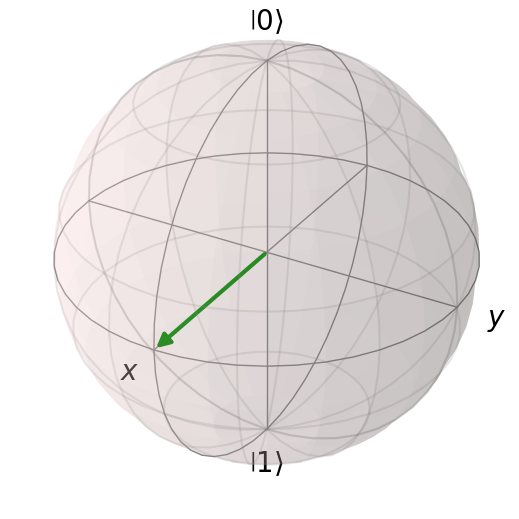

In [ ]:
# Bloch Sphere Visualization

b = Bloch()

b.add_vectors(bloch_vector)

b.show()

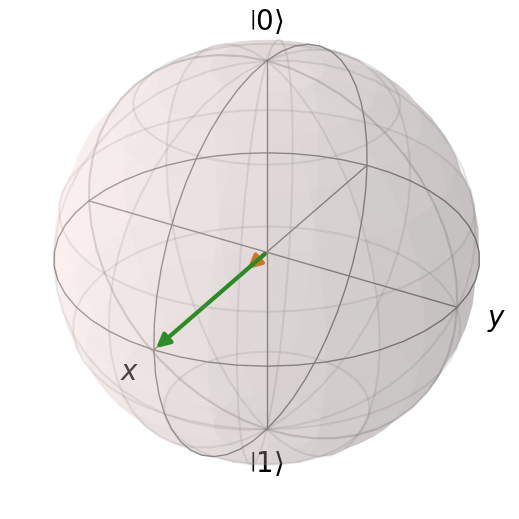

In [ ]:
# Bloch vector after Decoherence

rx = np.trace(rho_damped @ sigma_x).real
ry = np.trace(rho_damped @ sigma_y).real
rz = np.trace(rho_damped @ sigma_z).real

bloch_vector2 = [rx,ry,rz]

b = Bloch()
b.add_vectors(bloch_vector)
b.add_vectors(bloch_vector2)

b.show()

In [ ]:
# Bloch Sphere: Helper Functions

"""
Utility functions for Bloch sphere visualization
"""

sigma_x = np.array([[0,1],[1,0]])
sigma_y = np.array([[0,-1j],[1j,0]])
sigma_z = np.array([[1,0],[0,-1]])
I = np.eye(2)


def state_from_angles(theta, phi):
    """
    Construct qubit state:

    |ψ> = cos(θ/2)|0> + e^{iφ} sin(θ/2)|1>
    """

    alpha = np.cos(theta/2)
    beta = np.exp(1j*phi)*np.sin(theta/2)

    psi = np.array([[alpha],[beta]])

    return psi


def density_matrix(psi):
    """
    Compute density matrix ρ = |ψ><ψ|
    """

    return psi @ psi.conj().T


def bloch_vector(rho):
    """
    Compute Bloch vector components

    r_i = Tr(ρ σ_i)
    """

    rx = np.trace(rho @ sigma_x).real
    ry = np.trace(rho @ sigma_y).real
    rz = np.trace(rho @ sigma_z).real

    return np.array([rx,ry,rz])

In [ ]:
# Interactive Bloch Sphere with theta and phi

def interactive_bloch(theta, phi):

    psi = state_from_angles(theta, phi)
    rho = density_matrix(psi)

    r = bloch_vector(rho)

    b = Bloch()
    b.add_vectors(r)

    b.show()


interact(
    interactive_bloch,
    theta=FloatSlider(min=0,max=np.pi,step=0.05,value=np.pi/2),
    phi=FloatSlider(min=0,max=2*np.pi,step=0.05,value=0)
)

# Changing θ --> Moves state north–south
# Changing φ --> Rotates state around z-axis

interactive(children=(FloatSlider(value=1.5707963267948966, description='theta', max=3.141592653589793, step=0…

<function __main__.interactive_bloch(theta, phi)>

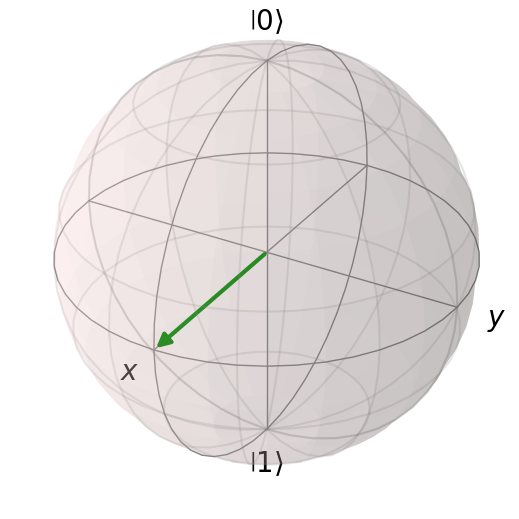

In [ ]:
# Rotations around Z-Axis
# This simulates a unitary evolution: U=e−iθσz​/2

import time
from IPython.display import clear_output

def animate_rotation_z():

    theta = np.pi/2
    psi = state_from_angles(theta,0)

    for phi in np.linspace(0,2*np.pi,60):

        psi = state_from_angles(theta,phi)
        rho = density_matrix(psi)
        r = bloch_vector(rho)

        clear_output(wait=True)

        b = Bloch()
        b.add_vectors(r)
        b.show()

        time.sleep(0.1)


animate_rotation_z()

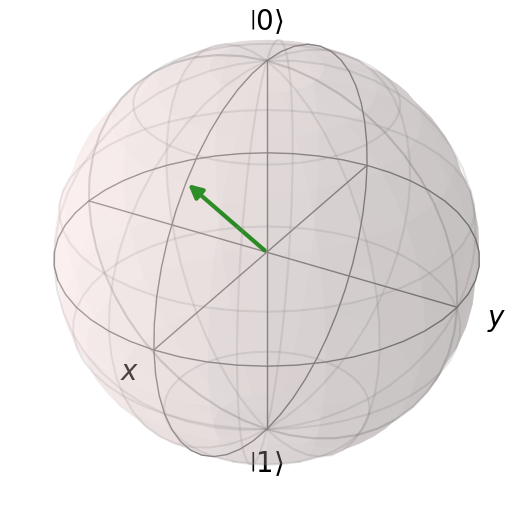

In [ ]:
# Animated Rotations around X-axis
# This simulates: U=e−iθσx​/2

def rotation_x(theta):

    return np.cos(theta/2)*I - 1j*np.sin(theta/2)*sigma_x


def animate_rotation_x():

    psi = state_from_angles(np.pi/4,0)

    for t in np.linspace(0,2*np.pi,60):

        U = rotation_x(t)

        psi_t = U @ psi
        rho = density_matrix(psi_t)

        r = bloch_vector(rho)

        clear_output(wait=True)

        b = Bloch()
        b.add_vectors(r)
        b.show()

        time.sleep(0.1)


animate_rotation_x()

In [ ]:
# Visualizing Bloch Sphere Coordinates
# This will help us see how θ and φ map to Bloch vector components.
# x=sinθcosϕ      𝑦=sinθsin⁡ϕ       z=cosθ

def bloch_coordinates(theta,phi):

    x = np.sin(theta)*np.cos(phi)
    y = np.sin(theta)*np.sin(phi)
    z = np.cos(theta)

    print("Bloch vector:")
    print("x =",x)
    print("y =",y)
    print("z =",z)


interact(
    bloch_coordinates,
    theta=FloatSlider(min=0,max=np.pi,step=0.05,value=np.pi/2),
    phi=FloatSlider(min=0,max=2*np.pi,step=0.05,value=0)
)

interactive(children=(FloatSlider(value=1.5707963267948966, description='theta', max=3.141592653589793, step=0…

<function __main__.bloch_coordinates(theta, phi)>

In [ ]:
# Summary

'''
Key Takeaways
State: ∣ψ⟩=cos(θ/2)∣0⟩+eiϕsin(θ/2)∣1⟩
Bloch Vector: r=(sinθcosϕ,sinθsinϕ,cosθ)

Pauli matrices: Form basis for qubit operators

Density matrices: Describe both pure and mixed states

Purity: Measures classical uncertainty

Coherence: Comes from off-diagonal terms

Bloch sphere: Visual representation of qubit states

Entanglement: Subsystems appear mixed even if the global state is pure
'''

'\nKey Takeaways\nState: ∣ψ⟩=cos(θ/2)∣0⟩+eiϕsin(θ/2)∣1⟩\nBloch Vector: r=(sinθcosϕ,sinθsinϕ,cosθ)\n\nPauli matrices: Form basis for qubit operators\n\nDensity matrices: Describe both pure and mixed states\n\nPurity: Measures classical uncertainty\n\nCoherence: Comes from off-diagonal terms\n\nBloch sphere: Visual representation of qubit states\n\nEntanglement: Subsystems appear mixed even if the global state is pure\n'